# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.


In [1]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [2]:
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


Imágenes listas para la actividad.


## Parte 1. Elegí una imagen y un color objetivo

Si completaste el cuaderno extra de preprocesamiento, te conviene empezar con `imagen_preprocesada.png`. Si no, podés trabajar con `flowers.jpg` o con `frutos_rojos.png`.

Antes de escribir código, anotá qué color querés segmentar y por qué te parece un buen caso para probar.


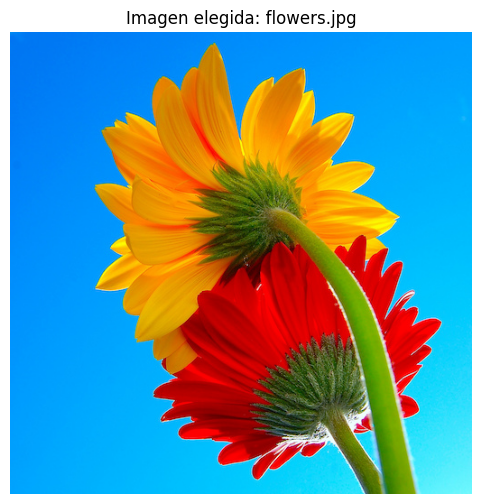

Color objetivo: Se busca segmentar el color amarillo, ya que la flor principal presenta alta intensidad en este color y contrasta claramente con el fondo azul.


In [9]:
# Elegí la imagen con la que vas a trabajar.
if Path("imagen_preprocesada.png").exists():
    nombre_imagen = "imagen_preprocesada.png"
else:
    nombre_imagen = "flowers.jpg"  # o "frutos_rojos.png"

imagen_rgb = cargar_rgb(nombre_imagen)

# Escribí en una frase qué color querés segmentar.
color_objetivo = "Se busca segmentar el color amarillo, ya que la flor principal presenta alta intensidad en este color y contrasta claramente con el fondo azul."

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)


## Parte 2. Explorá canales e histogramas

Antes de definir umbrales, mirá la imagen por canales y revisá sus histogramas. La pregunta clave es: ¿qué canal parece más útil para distinguir el color que querés aislar?


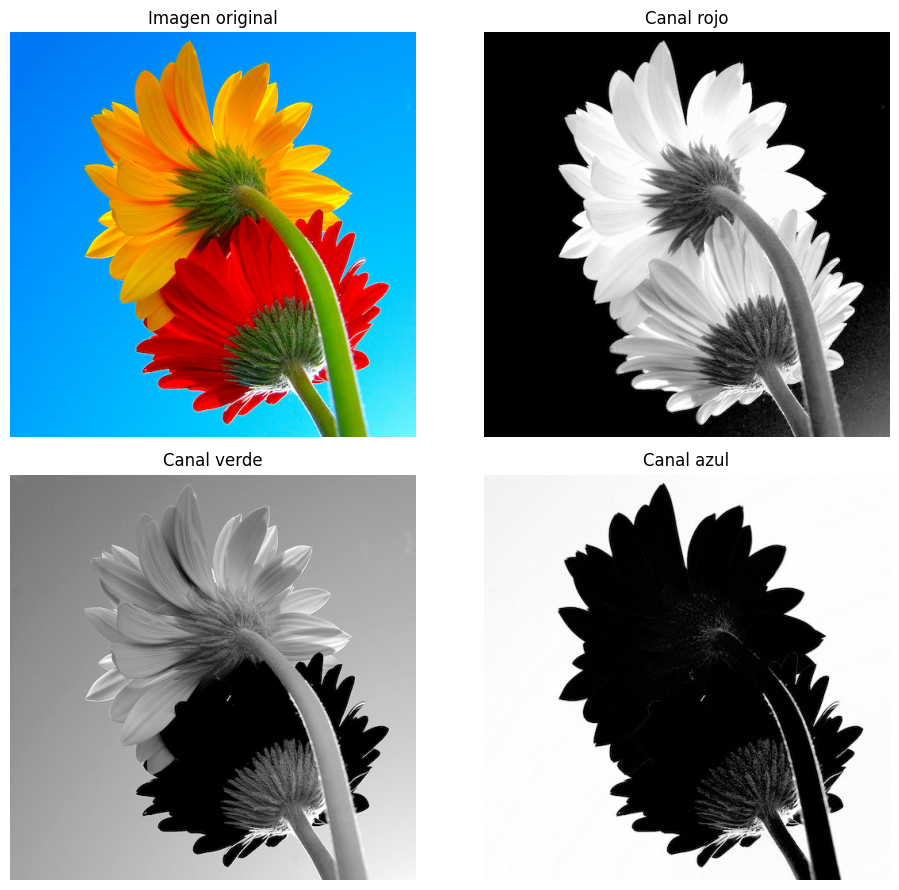

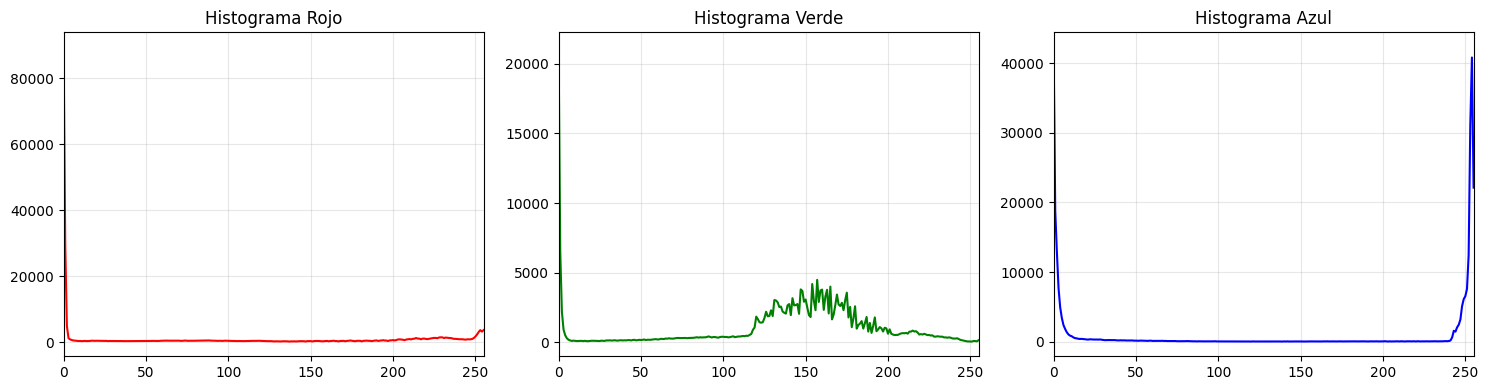

El canal verde parece ser el más útil para distinguir la flor amarilla del fondo, ya que en este canal la flor presenta valores altos mientras que el fondo azul aparece más oscuro. El canal rojo también aporta información, aunque no permite una separación tan clara. Por otro lado, el canal azul es útil para descartar el fondo, ya que este presenta valores altos en azul mientras que la flor aparece más oscura. Por lo tanto, la segmentación puede basarse en una combinación de rojo y verde altos, y azul bajo.


In [13]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)

# Escribí una observación breve sobre lo que viste.
observacion = "El canal verde parece ser el más útil para distinguir la flor amarilla del fondo, ya que en este canal la flor presenta valores altos mientras que el fondo azul aparece más oscuro. El canal rojo también aporta información, aunque no permite una separación tan clara. Por otro lado, el canal azul es útil para descartar el fondo, ya que este presenta valores altos en azul mientras que la flor aparece más oscura. Por lo tanto, la segmentación puede basarse en una combinación de rojo y verde altos, y azul bajo."
print(observacion)


## Parte 3. Diseñá tu primera estrategia de segmentación

Completá los rangos mínimos y máximos para cada canal. No tienen por qué ser perfectos en el primer intento. La idea es que puedas probar, mirar y corregir.


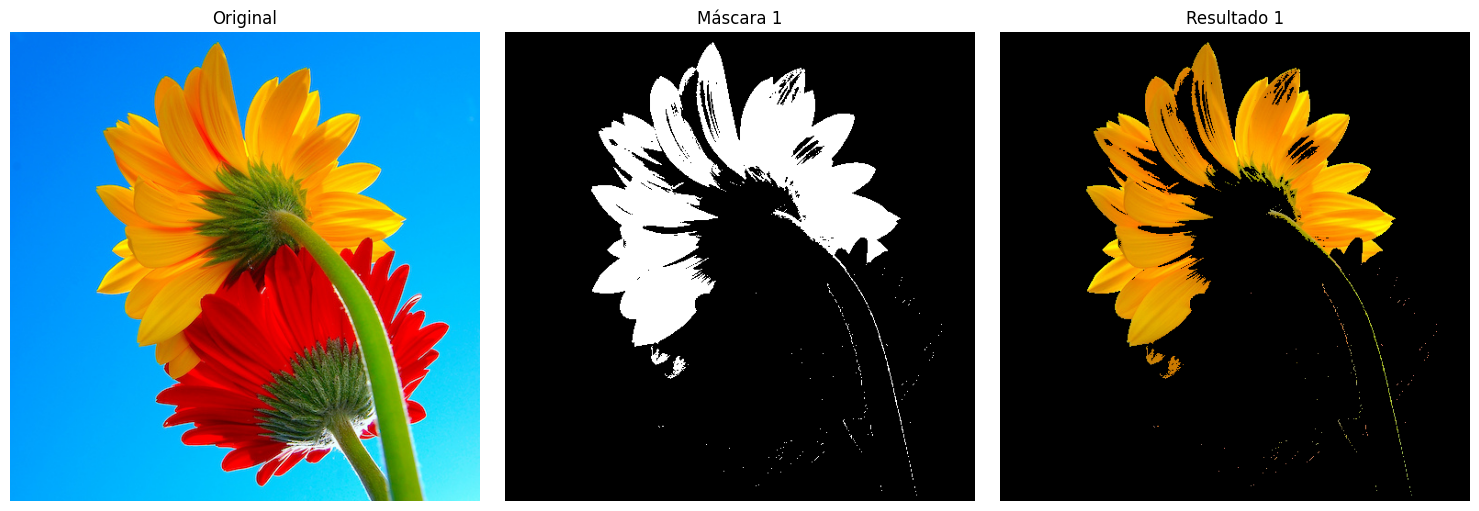

In [15]:
r_min, r_max = 150, 255
g_min, g_max = 120, 255
b_min, b_max = 0, 120

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)

resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Parte 4. Revisá y mejorá

Proponé una segunda estrategia. Puede cambiar solo un parámetro o varios. Después compará ambos resultados y explicá cuál conservarías.


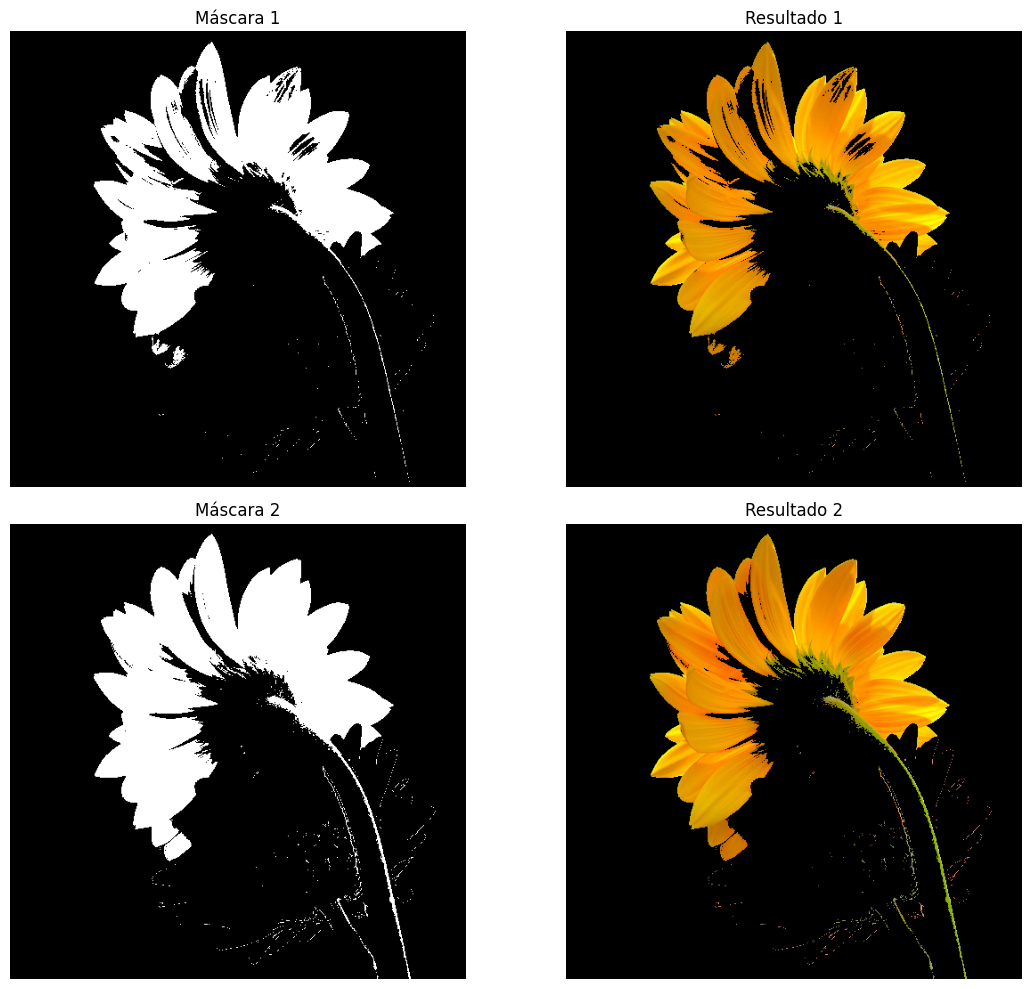

In [16]:
r_min_2, r_max_2 = 130, 255
g_min_2, g_max_2 = 100, 255
b_min_2, b_max_2 = 0, 140

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)

resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Parte 5. Cierre escrito

Respondé con tus palabras:

1. ¿Qué color intentaste segmentar? **Intente segmentar el color amarillo, ya que considero que la flor principal es amarilla **
2. ¿Qué canales te dieron la pista más útil? **tPrincipalmente el verde y el canal azul también, que me ayudo a descartar el fondo de la imagen**
3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia? **ajuste los umbrales para hacerlos menos estrictos. En la primera estrategia hay partes de la flor que no se detectaron, pero en la segunda se incluyo mucho mas  y se mejoro loa segmentación**
4. ¿Qué limitaciones encontraste en este método? **una de las mayores limitaciones de este metodo es que depende fuertemente del color. Si el fondo tuviera tonos similares al objeto de interes o si la iluminacion cambiara creo que pdoria fallar**
5. Si tuvieras más tiempo, ¿qué mejorarías? **Me gustaria hacer un trabajo mas preciso**

### Lista de control antes de entregar

- Mostré la imagen original.
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.
